### ETAPE 1 : CHARGEMENT, VISUALISATION ET JUSTIFICATIONDE LA FORME DU TENSEUR IMAGE

# Importation des packages necessaires au projet

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

### Chargement de l'image

In [2]:
img = Image.open("Images/image.jpg")

### Transformation en tableau numpy

In [3]:
image_numpy = np.array(img)

### Affichage de la forme du tenseur et justification simple de la forme du tenseur Image

In [4]:
print(f"la forme du tenseur [Image] est :{image_numpy.shape} \n"
      "dim(Image) = ", image_numpy.shape[0], 'x', image_numpy.shape[1], 'x', image_numpy.shape[2], '\n'
      "c'est a dire \nHauteur : ", image_numpy.shape[0], "\nLargeur : ", image_numpy.shape[1], "\nCannaux R G B : ", image_numpy.shape[2]
      )

la forme du tenseur [Image] est :(6000, 4000, 3) 
dim(Image) =  6000 x 4000 x 3 
c'est a dire 
Hauteur :  6000 
Largeur :  4000 
Cannaux R G B :  3


### Visualisation matplotlib 

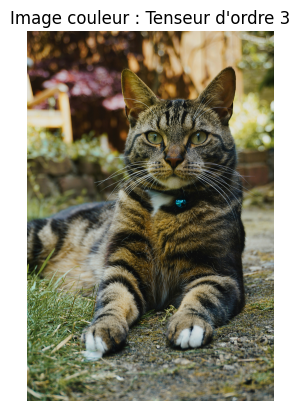

In [5]:
plt.imshow(image_numpy)
plt.axis("off")
plt.title("Image couleur : Tenseur d'ordre 3")
plt.show()

### ETAPE 2 : ETUDES DES OPERATIONS SIMPLES

### Le PIXEL : 
### c'est le plus petit point d'une image numérique, il definit l'intensité de la lumière à ce point on s'en servira pour mieux comprendre les operations sur le tenseur Image.

### La CONTRACTION TENSORIELLE : 
  ### c'est reduire un tenseur le long d'un ou plusieurs axes en somme pondéreé. On s'en servira ici specialement pour ramener les dimension de notre tenseur Images 3D (H x L x 3) en une matrice simple 2D de dimension (H x L) plus visualisable.

In [6]:
poids = np.array([0.294, 0.591, 0.114])
poids.shape

(3,)

### Le vecteur poids est le vecteurs de ponderations. Du point de vu fonctionel il peut ètre vu comme le vecteur qui affecte de l'importance aux couleurs
### L'idée est d'accorder plus d'importance aux couleurs qui attirent l'oeil humain ainsi on accorde plus d'importance a la couleur
### verte (0.591) ensuite vient la couleur rouge (0.294) et enfin la couleur blue (0.114) à qui nous acoordons le moin d'importance.

In [7]:
image_np_reshape = np.tensordot(image_numpy, poids, axes = ([2], [0]))

In [8]:
image_np_reshape

array([[ 43.134,  42.135,  39.138, ...,  26.22 ,  25.695,  27.693],
       [ 41.136,  41.136,  39.138, ...,  26.22 ,  26.694,  28.692],
       [ 38.958,  39.957,  39.957, ...,  26.22 ,  27.693,  29.691],
       ...,
       [ 39.087,  44.082,  44.082, ...,  99.042,  99.042,  95.046],
       [ 39.087,  44.082,  44.082, ...,  99.63 , 100.629,  94.635],
       [ 41.085,  45.081,  44.082, ..., 100.629, 100.629,  93.636]],
      shape=(6000, 4000))

In [9]:
print("la nouvelle forme du tenseur Image est :", image_np_reshape.shape)

la nouvelle forme du tenseur Image est : (6000, 4000)


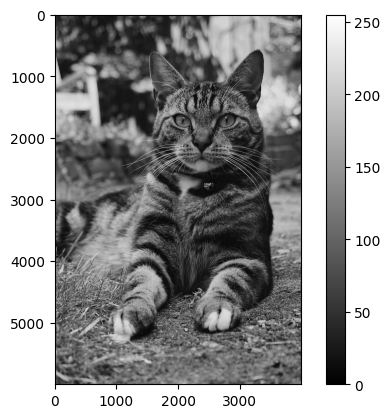

In [10]:
plt.imshow(image_np_reshape, cmap='gray', vmin=0, vmax=255)
plt.colorbar()  # montre l’échelle des valeurs
plt.show()

### Le FILTRAGE PAR CONVOLUTION : 
### Jusqu'ici on a etudier l'image en prenant les informations de chaque pixel de manière isolé. Mais que se passe t- il si on fait en sorte que chaque pixel contienne aussi les informations de ses pixels voisins ? Le filtrage par convolution est justement la clé d'une telle operation. 
### Le principe est simple : les nouvelles valeurs des pixels seront des combinaisons linéaire des pixels du voisinage

In [11]:
noyau = np.ones((3, 3), np.float32) / 9
noyau.shape

(3, 3)

### c'est un tableau double fonction dans le sens où il est d'une part la relation qui definie le rayon du voisinage et d'autre par, ses valeures servent de coéfficients de linéariter pour l'operation de la combinaison lineaire. 

In [12]:
image_filtre = cv2.filter2D(image_np_reshape, -1, noyau)

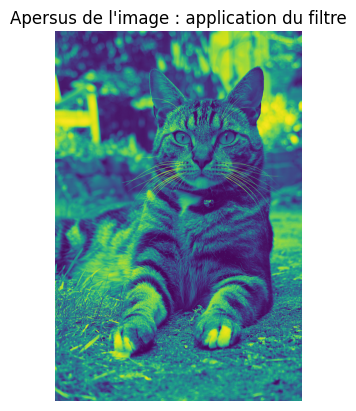

In [13]:
plt.imshow(image_filtre)
plt.axis("off")
plt.title("Apersus de l'image : application du filtre")
plt.show()

In [14]:
noyau1 = np.array([
    [-5, -1, 5],
    [-6,  1, 6],
    [-5, -1, 5]
], dtype=np.float32)
image_detecte_contoures = cv2.filter2D(image_np_reshape, -1, noyau1)

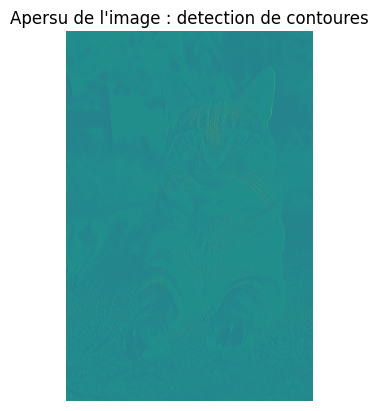

In [15]:
plt.imshow(image_detecte_contoures)
plt.axis("off")
plt.title("Apersu de l'image : detection de contoures")
plt.show()